In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import pickle, os, glob

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture as GMM
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics.pairwise import pairwise_distances
from scipy.spatial import distance_matrix
from sklearn.metrics import confusion_matrix
from sklearn import metrics
from mpl_toolkits.mplot3d import Axes3D
import time
import seaborn as sns


from tensorflow.keras.preprocessing.image import load_img, img_to_array, ImageDataGenerator

In [2]:
df_stratified = pickle.load(open("../Data/stratified_data.p", 'rb'))

In [3]:
df_stratified['articleType'] = df_stratified['articleType'].astype('category')
df_stratified['label'] = df_stratified['articleType'].cat.codes
df_stratified.head()
df_stratified = df_stratified.loc[:, ['id', 'label','articleType']]

In [4]:
df_stratified.head()

,id,label,articleType
0,55627,0,Casual Shoes
1,23930,0,Casual Shoes
2,22114,0,Casual Shoes
3,8996,0,Casual Shoes
4,24666,0,Casual Shoes


In [5]:
img_data = []

for i in df_stratified['id']:
    filepath = '../Images/' + str(i) + '.jpg'
    
    try:
        temp = load_img(filepath, target_size=(120, 120, 3))
        temp = img_to_array(temp).flatten()
        temp = temp / 255.0
        img_data.append(temp)
    except FileNotFoundError:
        continue

In [6]:
import numpy as np

img_data = np.array(img_data)
print(img_data.shape)

(29, 43200)


In [7]:
img_data

array([[0.99607843, 0.99607843, 0.99607843, ..., 0.99607843, 0.99607843,
        0.99607843],
       [1.        , 1.        , 1.        , ..., 1.        , 1.        ,
        1.        ],
       [1.        , 1.        , 1.        , ..., 1.        , 1.        ,
        1.        ],
       ...,
       [1.        , 1.        , 1.        , ..., 1.        , 1.        ,
        1.        ],
       [1.        , 1.        , 1.        , ..., 1.        , 1.        ,
        1.        ],
       [1.        , 1.        , 1.        , ..., 1.        , 1.        ,
        1.        ]], shape=(29, 43200), dtype=float32)

In [8]:
img_data = np.array(img_data, dtype = float)

In [9]:
# 88 images with dimension (n_images * (240*180*3)) 
img_data.shape

(29, 43200)

### Employing PCA for ~ 150 Components

In [10]:
from sklearn.decomposition import PCA

n_components = 20   # <= 29

pca = PCA(n_components=n_components)
pca_results = pca.fit_transform(img_data)

print(pca_results.shape)


(29, 20)


In [11]:
img_data = np.array(img_data)
print(img_data.shape)


(29, 43200)


### KMeans After PCA [ Only 150 Components]

In [12]:
cluster = []
# for i in range(1,6):
kmeans = KMeans(n_clusters = 5)
kmeans.fit(img_data)
cluster.append(kmeans.predict(img_data))

### TSNE on complete Dataset

In [13]:
tsne = TSNE(n_components=2, verbose=0, perplexity=30, n_iter=500)
tsne_results_img = tsne.fit_transform(img_data)

TypeError: TSNE.__init__() got an unexpected keyword argument 'n_iter'

In [ ]:
tsne_1 = tsne_results_img[:, 0]
tsne_2 = tsne_results_img[:, 1]
plt.title("TSNE PLot for Image Data with 2 components")
plt.scatter(tsne_1, tsne_2)

### TSNE on PCA Components

In [ ]:
tsne = TSNE(n_components=2, verbose=0, perplexity=30, n_iter=500)
tsne_results_pca = tsne.fit_transform(pca_results)

In [ ]:
df_stratified['tsne-2d-one'] = tsne_results_pca[:,0]
df_stratified['tsne-2d-two'] = tsne_results_pca[:,1]

tsne_1 = tsne_results_pca[:, 0]
tsne_2 = tsne_results_pca[:, 1]
# plt.title("TSNE PLot on PCA Components ")
# plt.scatter(tsne_1, tsne_2)


tsne = TSNE(n_components=2, verbose=1, perplexity=40, n_iter=300)
tsne_results = tsne.fit_transform(pca_results)

In [ ]:
df_stratified['pca-2d-one'] = pca_results[:,0]
df_stratified['pca-2d-two'] = pca_results[:,1]
plt.figure(figsize=(10,8))
sns.scatterplot(x="pca-2d-one", y="pca-2d-two",
                hue="articleType",
                data=df_stratified,
                legend="full",
                palette='viridis',
                alpha=0.8).set_title("PCA [2d Plot] on Original Train Dataset")
plt.savefig("PCAOriginal", dpi = 480)

In [ ]:
plt.figure(figsize=(10,8))
sns.scatterplot(x="tsne-2d-one", y="tsne-2d-two",
                hue="articleType",
                data=df_stratified,
                legend="full",
                palette='viridis',
                alpha=0.8).set_title("TSNE [2d Plot] on Original Train Dataset")
plt.savefig("OriginalTSNE", dpi = 480)

In [ ]:
cluster_li = []
for each in range(0,len(cluster)):
    for i in cluster[each]:
        cluster_li.append(i)

In [ ]:
df_result_tsne = pd.DataFrame(columns = ['tsne_2d_one', 'tsne_2d_two', 'cluster'])

for i, j, k in zip(tsne_1, tsne_2, cluster_li):
    df_result_tsne.loc[len(df_result_tsne)] = {'tsne_2d_one' : i, 'tsne_2d_two' : j, 'cluster' : int(k)}

In [ ]:
plt.figure(figsize=(10,8))
sns.set_palette("muted")
sns.scatterplot(x="tsne_2d_one", y="tsne_2d_two",
                hue="cluster",
                data=df_result_tsne,
                legend="full",
                alpha=0.8,
                palette='viridis_r'
               ).set_title("TSNE Plot [2D plot] of KMeans Clustering")
plt.savefig("tsneKMeans", dpi = 480)

### PCA

In [ ]:
cluster = []
# for i in range(1,6):
kmeans = KMeans(n_clusters = 5)
kmeans.fit(pca_results)
cluster.append(kmeans.predict(pca_results))

In [ ]:
cluster_li = []
for each in range(0,len(cluster)):
    for i in cluster[each]:
        cluster_li.append(i)
pca_1 = pca_results[:, 0]
pca_2 = pca_results[:, 1]
# label = np.array(df_stratified.label)
df_result_pca = pd.DataFrame(columns = ['pca_2d_one', 'pca_2d_two', 'cluster'])

for i, j, k in zip(pca_1, pca_2, cluster_li):
    df_result_pca.loc[len(df_result_pca)] = {'pca_2d_one' : i, 'pca_2d_two' : j, 'cluster' : int(k)}

In [ ]:
# ax = df_result_pca.plot.scatter(
#     x = 'pca_2d_one',
#     y = 'pca_2d_two',
#     c = 'label',
#     cmap = 'viridis',
#     alpha = 0.2
# )
# ax.set_xlabel("PCA 1")
# ax.set_ylabel("PCA 2")
# ax.set_title("PCA with original Labels")


plt.figure(figsize=(10,8))
sns.set_palette(sns.color_palette("muted", 7))
sns.scatterplot(x="pca_2d_one", y="pca_2d_two",
                hue="cluster",
                data=df_result_pca,
                legend="full",
                alpha=0.8,
                palette='viridis_r'
               ).set_title("PCA Plot [2d Plot] using KMeans Cluster Labels")
plt.savefig("pcaKmeans", dpi = 480)

### PCA and KMeans Clustering

In [ ]:
ax = df_result_pca.plot.scatter(
    x = 'pca_2d_one',
    y = 'pca_2d_two',
    c = 'cluster',
    cmap = 'viridis',
    alpha = 0.5
)
ax.set_xlabel("PCA 1")
ax.set_ylabel("PCA 2")
ax.set_title("KMeans Clustering -> PCA Plot")

### KMeans on PCA Components

In [ ]:
cluster = []
# for i in range(1,6):
kmeans = KMeans(n_clusters = 5)
kmeans.fit(tsne_results_pca)
cluster.append(kmeans.predict(tsne_results_pca))

In [ ]:
cluster_li = []
for each in range(0,len(cluster)):
    for i in cluster[each]:
        cluster_li.append(i)

In [ ]:
pca_1 = pca_results[:, 0]
pca_2 = pca_results[:, 1]
# label = np.array(df_stratified.label)
df_result_pca = pd.DataFrame(columns = ['pca_2d_one', 'pca_2d_two', 'cluster'])

for i, j, k in zip(pca_1, pca_2, cluster_li):
    df_result_pca.loc[len(df_result_pca)] = {'pca_2d_one' : i, 'pca_2d_two' : j, 'cluster' : int(k)}

In [ ]:
ax = df_result_pca.plot.scatter(
    x = 'pca_2d_one',
    y = 'pca_2d_two',
    c = 'cluster',
    cmap = 'viridis',
    alpha = 0.5
)
ax.set_xlabel("PCA 1")
ax.set_ylabel("PCA 2")
ax.set_title("PCA Components -> KMeans Clustering")

### KMeans on TSNE Components

In [ ]:
cluster = []
# for i in range(1,6):
kmeans = KMeans(n_clusters = 5)
kmeans.fit(tsne_results)
cluster.append(kmeans.predict(tsne_results))

cluster_li = []
for each in range(0,len(cluster)):
    for i in cluster[each]:
        cluster_li.append(i)

In [ ]:
df_result_tsne = pd.DataFrame(columns = ['tsne1', 'tsne2', 'label'])

for i, j, k in zip(tsne_1, tsne_2, df_stratified['label']):
    df_result_tsne.loc[len(df_result_tsne)] = {'tsne1' : i, 'tsne2' : j, 'label' : int(k)}

In [ ]:
ax = df_result_tsne.plot.scatter(
    x = 'tsne1',
    y = 'tsne2',
    c = 'label',
    cmap = 'viridis',
    alpha = 0.5
)
ax.set_xlabel("t-SNE 1")
ax.set_ylabel("t-SNE 2")
ax.set_title("T-SNE Plot on Original Labels")

In [ ]:
df_result_tsne = pd.DataFrame(columns = ['tsne1', 'tsne2', 'cluster'])

for i, j, k in zip(tsne_1, tsne_2, cluster_li):
    df_result_tsne.loc[len(df_result_tsne)] = {'tsne1' : i, 'tsne2' : j, 'cluster' : int(k)}

In [ ]:
ax = df_result_tsne.plot.scatter(
    x = 'tsne1',
    y = 'tsne2',
    c = 'cluster',
    cmap = 'viridis',
    alpha = 0.8
)
ax.set_xlabel("t-SNE 1")
ax.set_ylabel("t-SNE 2")
ax.set_title("T-SNE Plot -> KMeans Clustering")

### GMM Clustering with PCA and T-SNE

In [ ]:
cluster_gmm = []
gmm = GMM(n_components = 5)
gmm.fit(tsne_results_pca)
cluster_gmm.append(gmm.predict(tsne_results_pca))

In [ ]:
cluster_li_gmm = []
for each in range(0,len(cluster_gmm)):
    for i in cluster_gmm[each]:
        cluster_li_gmm.append(i)
        
df_result_tsne = pd.DataFrame(columns = ['tsne_2d_one', 'tsne_2d_two', 'cluster'])

for i, j, k in zip(tsne_1, tsne_2, cluster_li_gmm):
    df_result_tsne.loc[len(df_result_tsne)] = {'tsne_2d_one' : i, 'tsne_2d_two' : j, 'cluster' : int(k)}
    
plt.figure(figsize=(10,8))
# sns.set_palette(sns.color_palette("muted", 7))
sns.scatterplot(x="tsne_2d_one", y="tsne_2d_two",
                hue="cluster",
                data=df_result_tsne,
                legend="full",
                alpha=0.8,
                palette='viridis_r'
               ).set_title("TSNE Plot [2d Plot] using GMM Cluster Labels")
plt.savefig("TSNEGMM", dpi = 480)

# ax = df_result_tsne.plot.scatter(
# x = 'tsne1',
# y = 'tsne2',
# c = 'cluster',
# cmap = 'viridis',
# alpha = 0.8
# )
# ax.set_xlabel("t-SNE 1")
# ax.set_ylabel("t-SNE 2")
# ax.set_title("T-SNE Plot -> GMM Clustering")


In [ ]:
cluster_gmm = []
gmm = GMM(n_components = 5)
gmm.fit(pca_results)
cluster_gmm.append(gmm.predict(pca_results))

In [ ]:
# label = np.array(df_stratified.label)

cluster_pca_gmm = []
for each in range(0,len(cluster_gmm)):
    for i in cluster_gmm[each]:
        cluster_pca_gmm.append(i)
        
df_result_pca = pd.DataFrame(columns = ['pca_2d_one', 'pca_2d_two', 'cluster'])

for i, j, k in zip(pca_1, pca_2, cluster_li):
    df_result_pca.loc[len(df_result_pca)] = {'pca_2d_one' : i, 'pca_2d_two' : j, 'cluster' : int(k)}

plt.figure(figsize=(10,8))
sns.set_palette(sns.color_palette("muted", 7))
sns.scatterplot(x="pca_2d_one", y="pca_2d_two",
                hue="cluster",
                data=df_result_pca,
                legend="full",
                alpha=0.8,
                palette='viridis_r'
               ).set_title("PCA Plot [2d Plot] using GMM Cluster Labels")
plt.savefig("pcaGMM", dpi = 480)
    # ax = df_result_pca.plot.scatter(
#     x = 'pca_2d_one',
#     y = 'pca_2d_two',
#     c = 'cluster',
#     cmap = 'viridis',
#     alpha = 0.5
# )
# ax.set_xlabel("PCA 1")
# ax.set_ylabel("PCA 2")
# ax.set_title("PCA -> GMM Clustering")

In [16]:
# TRY WITH 150 COmponent
pca_150 = PCA( 
        n_components = 150,
        svd_solver = 'auto')
pca_150.fit(img_data)
pca_results_150 = pca_150.transform(img_data)

pca_1_150 = pca_results_150[:, 0]
pca_2_150 = pca_results_150[:, 1]

cluster_gmm = []
gmm = GMM(n_components = 5)
gmm.fit(pca_results_150)
cluster_gmm.append(gmm.predict(pca_results_150))
cluster_li = []
for each in range(0,len(cluster_gmm)):
    for i in cluster_gmm[each]:
        cluster_li.append(i)
        
df_result_pca = pd.DataFrame(columns = ['pca1', 'pca2', 'cluster'])

for i, j, k in zip(pca_1_150, pca_2_150, cluster_li):
    df_result_pca.loc[len(df_result_pca)] = {'pca1' : i, 'pca2' : j, 'cluster' : int(k)}

ax = df_result_pca.plot.scatter(
    x = 'pca_2d_one',
    y = 'pca_2d_two',
    c = 'cluster',
    cmap = 'viridis',
    alpha = 0.5
)
ax.set_xlabel("PCA 1")
ax.set_ylabel("PCA 2")
ax.set_title("PCA -> GMM Clustering")


ValueError: n_components=150 must be between 0 and min(n_samples, n_features)=29 with svd_solver='full'

### Agglomerative Clustering on PCA  components

In [17]:

clustering_img = AgglomerativeClustering(
linkage='ward',
n_clusters = 5).fit(tsne_results_pca)
labels = clustering_img.labels_



NameError: name 'tsne_results_pca' is not defined

In [18]:
# df_result_pca = pd.DataFrame(columns = ['pca1', 'pca2', 'cluster'])

# for i, j, k in zip(pca_1, pca_2, labels):
#     df_result_pca.loc[len(df_result_pca)] = {'pca1' : i, 'pca2' : j, 'cluster' : int(k)}

# ax = df_result_pca.plot.scatter(
#     x = 'pca_2d_one',
#     y = 'pca_2d_two',
#     c = 'cluster',
#     cmap = 'viridis',
#     alpha = 0.5
# )
# ax.set_xlabel("PCA 1")
# ax.set_ylabel("PCA 2")
# ax.set_title("PCA -> Agglomerative Clustering[Linkage-WARD]")

df_result_tsne = pd.DataFrame(columns = ['tsne_2d_one', 'tsne_2d_two', 'cluster'])

for i, j, k in zip(tsne_1, tsne_2, labels):
    df_result_tsne.loc[len(df_result_tsne)] = {'tsne_2d_one' : i, 'tsne_2d_two' : j, 'cluster' : int(k)}

plt.figure(figsize=(10,8))
# sns.set_palette(sns.color_palette("muted", 7))
sns.scatterplot(x="tsne_2d_one", y="tsne_2d_two",
                hue="cluster",
                data=df_result_tsne,
                legend="full",
                alpha=0.8,
                palette='viridis_r'
               ).set_title("TSNE Plot [2d Plot] using Hierarchial Cluster Labels [Linkage - Ward]")
plt.savefig("TSNEAggWard", dpi = 480)



NameError: name 'tsne_1' is not defined

In [19]:
clustering_pca_average = AgglomerativeClustering(
linkage='average',
n_clusters = 5).fit(pca_results)
labels = clustering_pca_average.labels_


In [20]:
df_result_pca = pd.DataFrame(columns = ['pca1', 'pca2', 'cluster'])

for i, j, k in zip(pca_1, pca_2, labels):
    df_result_pca.loc[len(df_result_pca)] = {'pca1' : i, 'pca2' : j, 'cluster' : int(k)}

ax = df_result_pca.plot.scatter(
    x = 'pca_2d_one',
    y = 'pca_2d_two',
    c = 'cluster',
    cmap = 'viridis',
    alpha = 0.5
)
ax.set_xlabel("PCA 1")
ax.set_ylabel("PCA 2")
ax.set_title("PCA -> Agglomerative Clustering[Linkage-AVERAGE]")

NameError: name 'pca_1' is not defined

In [21]:
clustering_pca_comp = AgglomerativeClustering(
linkage='complete',
n_clusters = 5).fit(pca_results)
labels = clustering_pca_comp.labels_

In [22]:
df_result_pca = pd.DataFrame(columns = ['pca1', 'pca2', 'cluster'])

for i, j, k in zip(pca_1, pca_2, labels):
    df_result_pca.loc[len(df_result_pca)] = {'pca1' : i, 'pca2' : j, 'cluster' : int(k)}

ax = df_result_pca.plot.scatter(
    x = 'pca_2d_one',
    y = 'pca_2d_two',
    c = 'cluster',
    cmap = 'viridis',
    alpha = 0.5
)
ax.set_xlabel("PCA 1")
ax.set_ylabel("PCA 2")
ax.set_title("PCA -> Agglomerative Clustering[Linkage-Complete]")

NameError: name 'pca_1' is not defined

### Agglomerative Clustering on TSNE Components

In [23]:

clustering_img = AgglomerativeClustering(
linkage='ward',
n_clusters = 5).fit(tsne_results)
labels = clustering_img.labels_


NameError: name 'tsne_results' is not defined

In [24]:

        
df_result_tsne = pd.DataFrame(columns = ['tsne1', 'tsne2', 'cluster'])

for i, j, k in zip(tsne_1, tsne_2, labels):
    df_result_tsne.loc[len(df_result_tsne)] = {'tsne1' : i, 'tsne2' : j, 'cluster' : int(k)}

ax = df_result_tsne.plot.scatter(
x = 'tsne1',
y = 'tsne2',
c = 'cluster',
cmap = 'viridis',
alpha = 0.8)

ax.set_xlabel("t-SNE 1")
ax.set_ylabel("t-SNE 2")
ax.set_title("T-SNE Plot -> Agglomerative Clustering[Linkage-WARD]")
plt.show()

NameError: name 'tsne_1' is not defined

In [25]:

clustering_img_average = AgglomerativeClustering(
linkage='average',
n_clusters = 5).fit(tsne_results)
labels = clustering_img_average.labels_


NameError: name 'tsne_results' is not defined

In [26]:
        
df_result_tsne = pd.DataFrame(columns = ['tsne1', 'tsne2', 'cluster'])

for i, j, k in zip(tsne_1, tsne_2, labels):
    df_result_tsne.loc[len(df_result_tsne)] = {'tsne1' : i, 'tsne2' : j, 'cluster' : int(k)}

ax = df_result_tsne.plot.scatter(
x = 'tsne1',
y = 'tsne2',
c = 'cluster',
cmap = 'viridis',
alpha = 0.8)

ax.set_xlabel("t-SNE 1")
ax.set_ylabel("t-SNE 2")
ax.set_title("T-SNE Plot -> Agglomerative Clustering[Linkage - Average]")
plt.show()

NameError: name 'tsne_1' is not defined

In [27]:

clustering_img_complete = AgglomerativeClustering(
linkage='complete',
n_clusters = 5).fit(tsne_results)
labels = clustering_img_complete.labels_


NameError: name 'tsne_results' is not defined

In [28]:
        
df_result_tsne = pd.DataFrame(columns = ['tsne1', 'tsne2', 'cluster'])

for i, j, k in zip(tsne_1, tsne_2, labels):
    df_result_tsne.loc[len(df_result_tsne)] = {'tsne1' : i, 'tsne2' : j, 'cluster' : int(k)}

ax = df_result_tsne.plot.scatter(
x = 'tsne1',
y = 'tsne2',
c = 'cluster',
cmap = 'viridis',
alpha = 0.8)

ax.set_xlabel("t-SNE 1")
ax.set_ylabel("t-SNE 2")
ax.set_title("T-SNE Plot -> Agglomerative Clustering[Linkage - COMPLETE]")
plt.show()

NameError: name 'tsne_1' is not defined

### TRYING Recommendation with KMeans

In [29]:
model = KMeans(n_clusters=5).fit(img_data)

In [30]:
model.cluster_centers_

array([[0.99921569, 0.99921569, 0.99921569, ..., 0.99921569, 0.99921569,
        0.99921569],
       [0.95058824, 0.95215687, 0.9482353 , ..., 0.97882353, 0.97882353,
        0.98039216],
       [1.        , 1.        , 1.        , ..., 1.        , 1.        ,
        1.        ],
       [0.99934641, 0.99934641, 0.99803922, ..., 1.        , 1.        ,
        1.        ],
       [1.        , 1.        , 1.        , ..., 1.        , 1.        ,
        1.        ]], shape=(5, 43200))

[3]


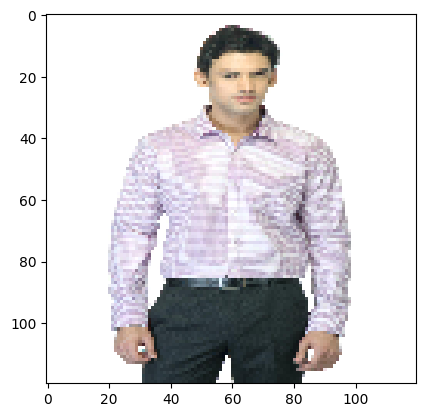

In [31]:
x = np.reshape(img_data[12], (1, len(img_data[0])))
print(model.predict(x))

y = np.reshape(x, (120,120,3))
plt.imshow(y)

In [32]:
x = np.reshape(img_data[1400], (1, len(img_data[1])))
print(model.predict(x))
y = np.reshape(x, (120,120,3))
plt.imshow(y)

IndexError: index 1400 is out of bounds for axis 0 with size 29

In [33]:
x = np.reshape(img_data[3100], (1, len(img_data[1])))
print(model.predict(x))
y = np.reshape(x, (120,120,3))
plt.imshow(y)

IndexError: index 3100 is out of bounds for axis 0 with size 29

In [34]:
x = np.reshape(img_data[4999], (1, len(img_data[1])))
print(model.predict(x))
y = np.reshape(x, (120,120,3))
plt.imshow(y)

IndexError: index 4999 is out of bounds for axis 0 with size 29

In [35]:
x = np.reshape(img_data[2000], (1, len(img_data[1])))
print(model.predict(x))
y = np.reshape(x, (120,120,3))
plt.imshow(y)

IndexError: index 2000 is out of bounds for axis 0 with size 29

In [36]:
labels = model.predict(img_data)

In [37]:
df_stratified['pred_labels'] = labels

ValueError: Length of values (29) does not match length of index (5000)

In [ ]:
df_sport = df_stratified[4000:5000]

In [38]:
li = []
for i in df_sport['pred_labels']:
    li.append(i)

NameError: name 'df_sport' is not defined

In [39]:
li.count(0), li.count(3), li.count(1), li.count(4), li.count(2)

(0, 0, 0, 0, 0)

In [40]:
df_formal = df_stratified[1000:2000]
li = []
for i in df_formal['pred_labels']:
    li.append(i)

KeyError: 'pred_labels'

In [ ]:
li.count(0), li.count(3), li.count(1), li.count(4), li.count(2)

In [ ]:
df_stratified

In [41]:
df_formal = df_stratified[4000:4999]
li = []
for i in df_formal['pred_labels']:
    li.append(i)

KeyError: 'pred_labels'

In [42]:
li.count(0), li.count(3), li.count(1), li.count(4), li.count(2)

(0, 0, 0, 0, 0)

In [43]:
img_id = 55627  
filepath = '../Images/' + str(img_id) + '.jpg'

temp = load_img(filepath, target_size=(120, 120, 3))
temp = img_to_array(temp).flatten()
temp /= 255


FileNotFoundError: [Errno 2] No such file or directory: '../Images/55627.jpg'

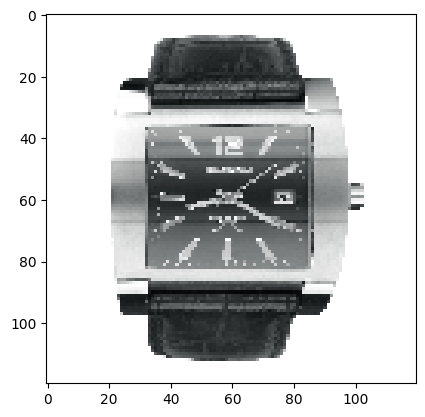

In [44]:
test_data = np.reshape(temp, (1,43200))
plt.imshow(np.reshape(test_data, (120,120,3)))

In [45]:
x = model.predict(test_data)

ValueError: Buffer dtype mismatch, expected 'const float' but got 'double'

In [46]:
map_dict = {'0':0,
           '1': 3,
            '2':1,
            '3':2,
            '4':4
           }
def cluster_predict(i, map_dict):
    return map_dict[str(i)]
    

In [47]:
# Prediciting the right cluster image
cluster_id = cluster_predict(int(x), map_dict)

TypeError: only length-1 arrays can be converted to Python scalars

In [48]:
images= []
def id_retrieve(df_stratified, cluster_id):
    if df_stratified['label'] == cluster_id:
        images.append(df_stratified['id'])

In [49]:
df_stratified

,id,label,articleType
0,55627,0,Casual Shoes
1,23930,0,Casual Shoes
2,22114,0,Casual Shoes
3,8996,0,Casual Shoes
4,24666,0,Casual Shoes
...,...,...,...
4995,50394,4,Watches
4996,29494,4,Watches
4997,45204,4,Watches
4998,11204,4,Watches


In [50]:
display_recommendation_cosine(test_data, 5)

NameError: name 'display_recommendation_cosine' is not defined

In [51]:
def get_recommendation_cosine(img, top_n):
    temp = np.vstack([img_data, img.reshape(1, -1)])
    l = len(temp)
    print(temp)
    cosine_sim = 1 - pairwise_distances(temp, metric='cosine')
    sim_scores = list(enumerate(cosine_sim[l-1]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
    sim_scores = sim_scores[1:top_n+1]
    idx_rec    = [i[0] for i in sim_scores]
    idx_sim    = [i[1] for i in sim_scores]
    return idx_rec, idx_sim

In [52]:
def display_recommendation_cosine(ref_img, top_n):
    
    #Getting recommendations
    idx_rec, idx_sim = get_recommendation_cosine(ref_img, top_n)
    rec_images = []
    for r in idx_rec:
        rec_images.append(img_data[r])
    rec_images = np.array(rec_images)
    
    #plotting original image
    plt.imshow(np.uint8(ref_img*255).reshape(120, 120, 3))
    plt.title("Original Image")
    plt.show()
    
    #Plotting recommendations
    fig, ax = plt.subplots(1, top_n, figsize=(8, 3))
    rec = rec_images.reshape(top_n, 120, 120, 3)
    for axi, center in zip(ax.flat, rec):
        axi.set(xticks=[], yticks=[])
        axi.imshow(center, interpolation='nearest', cmap=plt.cm.binary)
        

In [53]:
import os
os.listdir('../Images')[:10]


['10142.jpg',
 '10174.jpg',
 '10384.jpg',
 '10517.jpg',
 '10805.jpg',
 '11202.jpg',
 '12017.jpg',
 '12427.jpg',
 '12641.jpg',
 '13191.jpg']

(np.float64(-0.5), np.float64(119.5), np.float64(119.5), np.float64(-0.5))

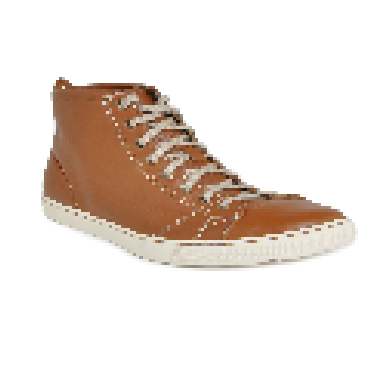

In [54]:
img_id = 10142
filepath = '../Images/' + str(img_id) + '.jpg'

temp = load_img(filepath, target_size=(120, 120, 3))
temp = img_to_array(temp)
plt.imshow(temp.astype('uint8'))
plt.axis('off')


In [55]:
from sklearn.metrics.pairwise import cosine_similarity

similarity_matrix = cosine_similarity(pca_results)
print(similarity_matrix.shape)


(29, 29)


In [56]:
query_index = 0


In [57]:
similar_scores = list(enumerate(similarity_matrix[query_index]))


In [58]:
similar_scores = sorted(similar_scores, key=lambda x: x[1], reverse=True)


In [59]:
top_matches = similar_scores[1:6]
top_matches


[(15, np.float64(0.7645840818615065)),
 (5, np.float64(0.6599844542407833)),
 (2, np.float64(0.642789033092752)),
 (4, np.float64(0.5467384870999219)),
 (7, np.float64(0.5296185478987466))]

In [60]:
import matplotlib.pyplot as plt


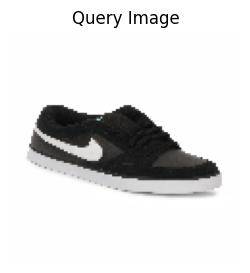

In [61]:
plt.figure(figsize=(3,3))
plt.imshow(img_data[query_index].reshape(120,120,3))
plt.title("Query Image")
plt.axis("off")
plt.show()


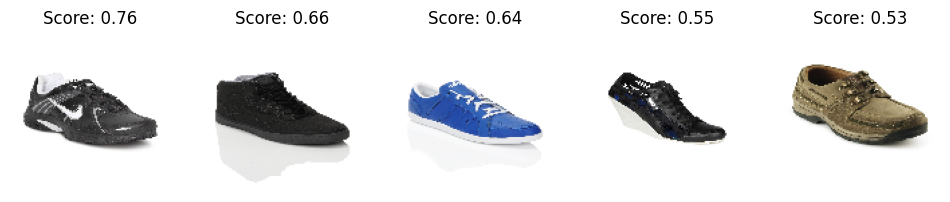

In [62]:
plt.figure(figsize=(12,3))

for i, (idx, score) in enumerate(top_matches):
    plt.subplot(1, 5, i+1)
    plt.imshow(img_data[idx].reshape(120,120,3))
    plt.title(f"Score: {score:.2f}")
    plt.axis("off")

plt.show()


In [63]:
top_matches = similar_scores[1:11]


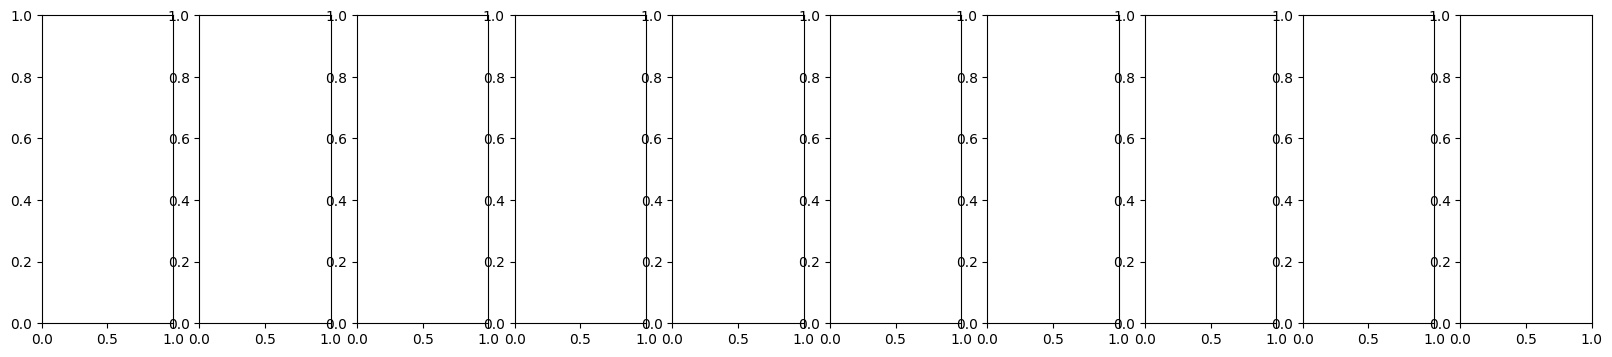

In [64]:
plt.figure(figsize=(20,4))

for i, (idx, score) in enumerate(top_matches):
    plt.subplot(1, 10, i+1)


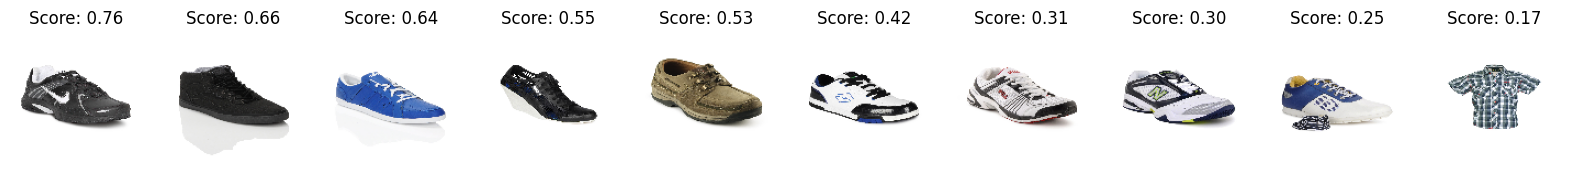

In [65]:
plt.figure(figsize=(20,4))

for i, (idx, score) in enumerate(top_matches):
    plt.subplot(1, len(top_matches), i+1)
    plt.imshow(img_data[idx].reshape(120,120,3))
    plt.title(f"Score: {score:.2f}")
    plt.axis('off')

plt.show()


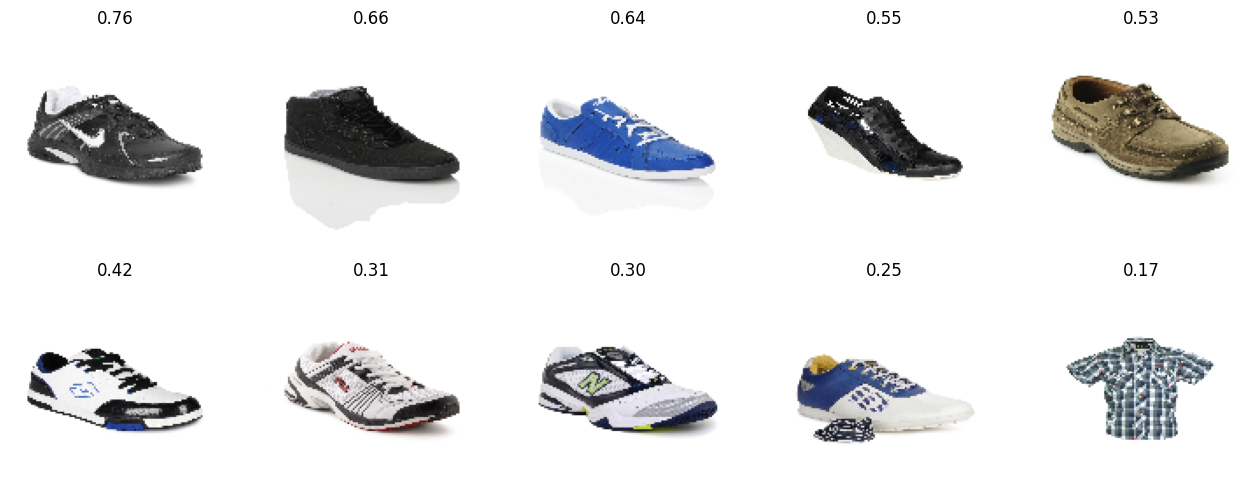

In [66]:
plt.figure(figsize=(16,6))

for i, (idx, score) in enumerate(top_matches):
    plt.subplot(2, 5, i+1)
    plt.imshow(img_data[idx].reshape(120,120,3))
    plt.title(f"{score:.2f}")
    plt.axis('off')

plt.show()


In [67]:
import matplotlib.pyplot as plt

In [15]:
plt.figure(figsize=(6,3))

for i, (idx, score) in enumerate(top_matches[:2]):  # only first 2
    plt.subplot(1, 2, i+1)  # 1 row, 2 columns
    plt.imshow(img_data[idx].reshape(120,120,3))
    plt.title(f"{score:.2f}")
    plt.axis('off')

plt.show()

NameError: name 'top_matches' is not defined

<Figure size 600x300 with 0 Axes>